In [1]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
from google.oauth2 import service_account

credentials = service_account.Credentials.from_service_account_file("key.json") # lokalizacja pobranego klucza z punktu 1.4.

client = bigquery.Client(credentials=credentials, project=credentials.project_id) 

In [2]:
gsod:pd.DataFrame
if False:
    query = """
    SELECT *
    FROM `bigquery-public-data.noaa_gsod.gsod*` WHERE _TABLE_SUFFIX BETWEEN '2020' AND '2023'
    """

    query_job = client.query(query)
    query_result = query_job.result()
    gsod = query_result.to_dataframe()
    gsod.to_csv("gsod2020.csv.gz", index=False)
else:
    gsod = pd.read_csv("gsod2020.csv.gz")


In [5]:
gsod["wban"] = gsod["wban"].apply(lambda x: str(x).zfill(5))
gsod

,stn,wban,date,year,mo,da,temp,count_temp,dewp,count_dewp,...,flag_min,prcp,flag_prcp,sndp,fog,rain_drizzle,snow_ice_pellets,hail,thunder,tornado_funnel_cloud
0,722700,23044,2020-11-24,2020,11,24,63.8,24,25.5,24,...,NaN,0.00,G,999.9,0,0,0,0,0,0
1,722730,03124,2020-07-20,2020,7,20,82.9,24,45.6,24,...,NaN,0.00,G,999.9,0,0,0,0,0,0
2,722783,03185,2020-03-23,2020,3,23,65.6,24,42.7,24,...,NaN,0.00,G,999.9,0,0,0,0,0,0
3,723759,53990,2020-10-23,2020,10,23,67.9,24,62.0,24,...,*,99.99,NaN,999.9,0,1,0,0,1,0
4,724035,13773,2020-03-31,2020,3,31,53.2,24,38.4,21,...,*,0.00,G,999.9,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16179196,262330,99999,2020-06-24,2020,6,24,69.5,24,52.4,24,...,NaN,0.00,I,999.9,0,0,0,0,0,0
16179197,341220,99999,2020-08-02,2020,8,2,62.4,24,52.8,24,...,*,99.99,NaN,999.9,0,1,0,0,0,0
16179198,375491,99999,2020-02-01,2020,2,1,27.0,24,23.7,24,...,*,0.00,I,999.9,0,0,0,0,0,0
16179199,378630,99999,2020-04-09,2020,4,9,43.0,24,33.0,24,...,*,0.00,I,999.9,1,0,0,0,0,0


In [6]:
isd = pd.read_csv("https://www.ncei.noaa.gov/pub/data/noaa/isd-history.csv")
isd.head()

,USAF,WBAN,STATION NAME,CTRY,STATE,ICAO,LAT,LON,ELEV(M),BEGIN,END
0,007018,99999,WXPOD 7018,NaN,NaN,NaN,0.00,0.000,7018.0,20110309,20130730
1,007026,99999,WXPOD 7026,AF,NaN,NaN,0.00,0.000,7026.0,20120713,20170822
2,007070,99999,WXPOD 7070,AF,NaN,NaN,0.00,0.000,7070.0,20140923,20150926
3,008260,99999,WXPOD8270,NaN,NaN,NaN,0.00,0.000,0.0,20050101,20120731
4,008268,99999,WXPOD8278,AF,NaN,NaN,32.95,65.567,1156.7,20100519,20120323


In [39]:
country_codes = pd.read_csv("https://raw.githubusercontent.com/mysociety/gaze/refs/heads/master/data/fips-10-4-to-iso-country-codes.csv")
country_codes.head()

,FIPS 10-4,ISO 3166,Name
0,AF,AF,Afghanistan
1,AX,-,Akrotiri
2,AL,AL,Albania
3,AG,DZ,Algeria
4,AQ,AS,American Samoa


In [40]:
country_codes = country_codes[country_codes["FIPS 10-4"] != "-"] # dla lokalizacji np "World"
country_codes[country_codes["ISO 3166"] == "-"]

,FIPS 10-4,ISO 3166,Name
1,AX,-,Akrotiri
66,DX,-,Dhekelia
77,PJ,-,"Etorofu, Habomai, Kunashiri, and Shikotan Islands"
135,KV,-,Kosovo
191,PF,-,Paracel Islands
229,PG,-,Spratly Islands


In [46]:
country_codes.loc[country_codes["FIPS 10-4"] == "AX", "ISO 3166"] = "GR"
country_codes.loc[country_codes["FIPS 10-4"] == "DX", "ISO 3166"] = "CY"
country_codes.loc[country_codes["FIPS 10-4"] == "PJ", "ISO 3166"] = "RU"
country_codes.loc[country_codes["FIPS 10-4"] == "KV", "ISO 3166"] = "XK"
country_codes.loc[country_codes["FIPS 10-4"] == "PF", "ISO 3166"] = "CN"
country_codes.loc[country_codes["FIPS 10-4"] == "PG", "ISO 3166"] = "VN"

In [47]:
stations = isd.merge(
    country_codes, 
    how="left", 
    left_on="CTRY", 
    right_on="FIPS 10-4"
)
stations.rename(columns={
    "USAF":"stn", 
    "WBAN":"wban", 
    "Name": "Country", 
    "STATION NAME": "Station Name", 
    "STATE": "State", 
    "LAT": "lat", 
    "LON": "lon", 
    "FIPS 10-4": "CTRY_FIPS", 
    "ISO 3166": "CTRY_ISO"
    }, inplace=True)
stations = stations[["stn", "wban", "Station Name", "Country", "State", "lat", "lon", "CTRY_ISO", "CTRY_FIPS"]]
stations["wban"] = stations["wban"].apply(lambda x: str(x).zfill(5))
stations


,stn,wban,Station Name,Country,State,lat,lon,CTRY_ISO,CTRY_FIPS
0,007018,99999,WXPOD 7018,NaN,NaN,0.000,0.000,NaN,NaN
1,007026,99999,WXPOD 7026,Afghanistan,NaN,0.000,0.000,AF,AF
2,007070,99999,WXPOD 7070,Afghanistan,NaN,0.000,0.000,AF,AF
3,008260,99999,WXPOD8270,NaN,NaN,0.000,0.000,NaN,NaN
4,008268,99999,WXPOD8278,Afghanistan,NaN,32.950,65.567,AF,AF
...,...,...,...,...,...,...,...,...,...
29728,A07355,00241,VIROQUA MUNICIPAL AIRPORT,United States,WI,43.579,-90.913,US,US
29729,A07357,00182,ELBOW LAKE MUNICIPAL PRIDE OF THE PRAIRIE AIRPORT,United States,MN,45.986,-95.992,US,US
29730,A07359,00240,IONIA COUNTY AIRPORT,United States,MI,42.938,-85.061,US,US
29731,A51255,00445,DEMOPOLIS MUNICIPAL AIRPORT,United States,AL,32.464,-87.954,US,US


In [48]:
df = gsod.merge(stations, how="left", on=["stn", "wban"])

In [49]:
df

,stn,wban,date,year,mo,da,temp,count_temp,dewp,count_dewp,...,hail,thunder,tornado_funnel_cloud,Station Name,Country,State,lat,lon,CTRY_ISO,CTRY_FIPS
0,722700,23044,2020-11-24,2020,11,24,63.8,24,25.5,24,...,0,0,0,EL PASO INTERNATIONAL AIRPORT,United States,TX,31.812,-106.377,US,US
1,722730,03124,2020-07-20,2020,7,20,82.9,24,45.6,24,...,0,0,0,SIERRA VISTA MUNICIPAL-LIBBY AAF AIRPORT,United States,AZ,31.588,-110.344,US,US
2,722783,03185,2020-03-23,2020,3,23,65.6,24,42.7,24,...,0,0,0,FALCON FIELD AIRPORT,United States,AZ,33.466,-111.721,US,US
3,723759,53990,2020-10-23,2020,10,23,67.9,24,62.0,24,...,0,1,0,MC CURTAIN COUNTY REGIONAL AIRPORT,United States,OK,33.909,-94.859,US,US
4,724035,13773,2020-03-31,2020,3,31,53.2,24,38.4,21,...,0,0,0,QUANTICO MCAF,United States,VA,38.504,-77.305,US,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16241440,262330,99999,2020-06-24,2020,6,24,69.5,24,52.4,24,...,0,0,0,VILJANDI,Estonia,NaN,58.367,25.600,EE,EN
16241441,341220,99999,2020-08-02,2020,8,2,62.4,24,52.8,24,...,0,0,0,CHERTOVITSKOYE,Russia,NaN,51.814,39.230,RU,RS
16241442,375491,99999,2020-02-01,2020,2,1,27.0,24,23.7,24,...,0,0,0,MESTIA,Georgia,NaN,43.069,42.754,GE,GG
16241443,378630,99999,2020-04-09,2020,4,9,43.0,24,33.0,24,...,0,0,0,GYANDZHA,Azerbaijan,NaN,40.733,46.400,AZ,AJ


In [66]:
df.columns

Index(['stn', 'wban', 'date', 'year', 'mo', 'da', 'temp', 'count_temp', 'dewp',
       'count_dewp', 'slp', 'count_slp', 'stp', 'count_stp', 'visib',
       'count_visib', 'wdsp', 'count_wdsp', 'mxpsd', 'gust', 'max', 'flag_max',
       'min', 'flag_min', 'prcp', 'flag_prcp', 'sndp', 'fog', 'rain_drizzle',
       'snow_ice_pellets', 'hail', 'thunder', 'tornado_funnel_cloud',
       'Station Name', 'Country', 'State', 'lat', 'lon', 'CTRY_ISO',
       'CTRY_FIPS'],
      dtype='object')

Czyszczenie danych z nieprawidłowych wartości

In [50]:
df["temp"] = df["temp"].replace(9999.9, np.nan)
df["dewp"] = df["dewp"].replace(9999.9, np.nan)
df["slp"] = df["slp"].replace(9999.9, np.nan)
df["stp"] = df["stp"].replace(9999.9, np.nan) # podejrzana max wartość 999.9 (ale to blisko 1 bar)
df["visib"] = df["visib"].replace(999.9, np.nan)
df["wdsp"] = df["wdsp"].replace(999.9, np.nan)
df["mxpsd"] = df["mxpsd"].replace(999.9, np.nan)
df["gust"] = df["gust"].replace(999.9, np.nan)
df["max"] = df["max"].replace(9999.9, np.nan)
df["min"] = df["min"].replace(9999.9, np.nan)
df["prcp"] = df["prcp"].replace(99.99, np.nan)
df["sndp"] = df["sndp"].replace(999.9, np.nan)

In [51]:
df["fog"] = df["fog"].astype('bool')
df["rain_drizzle"] = df["rain_drizzle"].astype('bool')
df["snow_ice_pellets"] = df["snow_ice_pellets"].astype('bool')
df["hail"] = df["hail"].astype('bool')
df["thunder"] = df["thunder"].astype('bool')
df["tornado_funnel_cloud"] = df["tornado_funnel_cloud"].astype('bool')

df["date"] = pd.to_datetime(df["date"])

In [52]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,16241445,2021-12-28 07:05:43.919472640,2020-01-01 00:00:00,2020-12-25 00:00:00,2021-12-26 00:00:00,2022-12-31 00:00:00,2023-12-31 00:00:00,NaN
year,16241445.0,2021.491557,2020.0,2020.0,2021.0,2022.0,2023.0,1.121801
mo,16241445.0,6.523093,1.0,4.0,7.0,10.0,12.0,3.458638
da,16241445.0,15.728192,1.0,8.0,16.0,23.0,31.0,8.807225
temp,16241445.0,55.703527,-114.3,41.8,58.6,73.7,110.0,22.951568
count_temp,16241445.0,18.278098,4.0,8.0,24.0,24.0,24.0,7.486719
dewp,15476567.0,44.325015,-122.1,31.2,46.2,60.2,90.0,21.696428
count_dewp,16241445.0,17.210067,0.0,8.0,23.0,24.0,24.0,8.286336
slp,10627346.0,1014.401149,904.4,1009.3,1014.1,1019.6,1077.7,9.218212
count_slp,16241445.0,10.375116,0.0,0.0,8.0,23.0,24.0,9.860769


3.1 Ilość wierszy z danymi

In [53]:
f"{len(df):_}"

'16_241_445'

3.2 Ilość krajów

In [54]:
df["CTRY_ISO"].unique()

array(['US', 'CU', 'BR', 'AR', 'UM', 'NZ', 'AU', nan, 'RO', 'BG', 'IT',
       'TR', 'RU', 'CA', 'GD', 'UY', 'GB', 'AT', 'MY', 'HN', 'FI', 'HR',
       'KZ', 'ZA', 'MX', 'ID', 'GR', 'AQ', 'IR', 'DK', 'CN', 'JP', 'EG',
       'NO', 'SC', 'SE', 'FR', 'DZ', 'BF', 'CO', 'CL', 'KE', 'AO', 'PL',
       'KR', 'KH', 'EC', 'GA', 'BE', 'UZ', 'SG', 'MA', 'PE', 'SK', 'IL',
       'SN', 'GL', 'IE', 'ES', 'DE', 'CZ', 'HU', 'SI', 'CY', 'LV', 'SY',
       'NL', 'SA', 'TN', 'TD', 'LI', 'PT', 'IN', 'UG', 'PY', 'GU', 'NC',
       'WF', 'TW', 'TH', 'TO', 'FM', 'AZ', 'GS', 'PW', 'AS', 'PR', 'CR',
       'CK', 'SX', 'MQ', 'LT', 'MR', 'QA', 'MG', 'CI', 'ZM', 'YT', 'PG',
       'SJ', 'KW', 'FK', 'EE', 'MK', 'BO', 'AE', 'IS', 'CH', 'LB', 'SV',
       'CV', 'IO', 'RE', 'AW', 'KG', 'MM', 'VI', 'MU', 'AG', 'TT', 'NP',
       'TV', 'PF', 'MD', 'OM', 'KP', 'VE', 'BA', 'NI', 'LA', 'MP', 'SL',
       'NE', 'CF', 'BI', 'RS', 'PK', 'LK', 'LY', 'BT', 'UA', 'KY', 'ME',
       'MZ', 'LU', 'KM', 'TG', 'ML', 'BY', 'PH', 'TZ

In [58]:
len(df["CTRY_ISO"].unique())

230

3.3. W jaki sposób zapisywane są dzienne informacje dla poszczególnych lokalizacji.

In [59]:
df[["stn", "wban", "date", "year", "mo", "da"]].head()

,stn,wban,date,year,mo,da
0,722700,23044,2020-11-24,2020,11,24
1,722730,03124,2020-07-20,2020,7,20
2,722783,03185,2020-03-23,2020,3,23
3,723759,53990,2020-10-23,2020,10,23
4,724035,13773,2020-03-31,2020,3,31


3.4. Jak zapisane są wartości liczbowe

Chyba stopnie Fahrenheita

In [60]:
df["temp"]

0           63.8
1           82.9
2           65.6
3           67.9
4           53.2
            ... 
16241440    69.5
16241441    62.4
16241442    27.0
16241443    43.0
16241444    58.2
Name: temp, Length: 16241445, dtype: float64

3.5 Przedział czasowy

In [61]:
df["date"].describe().T

count                         16241445
mean     2021-12-28 07:05:43.919472640
min                2020-01-01 00:00:00
25%                2020-12-25 00:00:00
50%                2021-12-26 00:00:00
75%                2022-12-31 00:00:00
max                2023-12-31 00:00:00
Name: date, dtype: object

In [62]:
df[(df["prcp"].notna()) & (df["date"] != 0)]["date"].describe().T

count                         14993214
mean     2021-12-27 06:32:56.807589376
min                2020-01-01 00:00:00
25%                2020-12-24 00:00:00
50%                2021-12-25 00:00:00
75%                2022-12-29 00:00:00
max                2023-12-31 00:00:00
Name: date, dtype: object

In [63]:
df[(df["temp"].notna())]["date"].describe().T

count                         16241445
mean     2021-12-28 07:05:43.919472640
min                2020-01-01 00:00:00
25%                2020-12-25 00:00:00
50%                2021-12-26 00:00:00
75%                2022-12-31 00:00:00
max                2023-12-31 00:00:00
Name: date, dtype: object

3.6 Więcej informacji o danych pogodowych.

In [64]:
df[["dewp", "temp", "fog", "wdsp", "snow_ice_pellets"]]

,dewp,temp,fog,wdsp,snow_ice_pellets
0,25.5,63.8,False,13.8,False
1,45.6,82.9,False,6.8,False
2,42.7,65.6,False,4.7,False
3,62.0,67.9,False,7.6,False
4,38.4,53.2,False,7.1,False
...,...,...,...,...,...
16241440,52.4,69.5,False,2.1,False
16241441,52.8,62.4,False,5.6,False
16241442,23.7,27.0,False,3.2,False
16241443,33.0,43.0,True,4.2,False


4.1. Podstawowe informacje o lokalizacjach pomiarów pogodowych (stacje) oraz krajach, tak aby dane były zrozumiałe dla człowieka i możliwe do dalszego przetwarzania.

In [72]:
existing_stations = df[["stn", "wban", "Station Name", "CTRY_ISO", "State", "lat", "lon"]].drop_duplicates()

existing_stations.to_csv("stations.csv", index=False)

4.2. Chcemy wygenerować podstawowe zestawienia dotyczące warunków pogodowych na świecie (np. temperatura, opady, wiatr) w ujęciu dziennym.

In [81]:

simplified_df = df.sort_values("date")[["date", "stn", "Station Name", "CTRY_ISO", "wban", "temp", "prcp", "wdsp"]]

In [77]:
simplified_df.to_csv("weather.csv.gz", index=False)

4.3. Chcemy poznać zjawiska ekstremalne w danych pogodowych poprzez uwypuklenie skrajnych wartości (np. bardzo wysokie/niskie temperatury, intensywne opady, silny wiatr).

In [82]:
temp_low, temp_high = simplified_df['temp'].quantile([0.01, 0.99])
prcp_high = simplified_df['prcp'].quantile(0.99)
wdsp_high = simplified_df['wdsp'].quantile(0.99)

# filtrowanie ekstremów
extreme_records = simplified_df[
    (simplified_df['temp'] < temp_low) | (simplified_df['temp'] > temp_high) |
    (simplified_df['prcp'] > prcp_high) |
    (simplified_df['wdsp'] > wdsp_high)
]
extreme_records.to_csv("extreme_weather.csv", index=False)

In [83]:
extreme_records

,date,stn,Station Name,CTRY_ISO,wban,temp,prcp,wdsp
11411717,2020-01-01,256480,SLAUTNOE,RU,99999,-41.3,0.00,2.3
9932490,2020-01-01,246610,SEGEN-KYUEL',RU,99999,-49.3,0.00,NaN
13429540,2020-01-01,011330,LAKSFORS,NO,99999,43.4,1.53,5.3
7553533,2020-01-01,013500,FINSEVATN,NO,99999,28.0,0.69,32.7
13284134,2020-01-01,246390,NJURBA,RU,99999,-23.4,0.03,NaN
...,...,...,...,...,...,...,...,...
880684,2023-12-31,713550,ALERT CLIMATE NU,CA,99999,-19.7,0.00,1.6
16127461,2023-12-31,251290,KONSTANTINOVSKAYA,RU,99999,-38.8,0.00,0.7
7678403,2023-12-31,912120,GUAM INTERNATIONAL AIRPORT,GU,41415,81.0,1.37,11.8
10400738,2023-12-31,063210,EURO PLATFORM,NL,99999,49.5,NaN,32.7


4.4. Chcemy przygotować dane umożliwiające analizę zmian warunków pogodowych w czasie (np. dla wybranych lokalizacji lub zmiennych).

In [85]:
lask_weather = simplified_df[simplified_df["Station Name"] == "LASK"]
lask_weather.to_csv("lask_weather.csv", index=False)

<Axes: title={'center': 'Temperature over time in LASK station'}, xlabel='Date', ylabel='Temperature (°F)'>

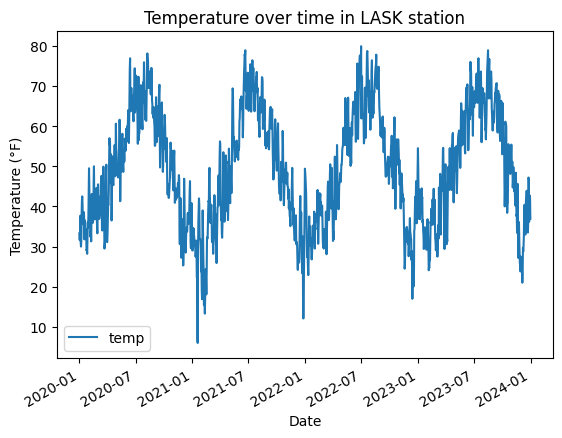

In [86]:
lask_weather.plot(x="date", y="temp", title="Temperature over time in LASK station", ylabel="Temperature (°F)", xlabel="Date")

4.5. Zdefiniuj własny dodatkowy przypadek związany z danymi pogodowymi.

In [87]:
custom_weather = simplified_df[(simplified_df["temp"] < 32) & (simplified_df["prcp"] > 0)]
custom_weather.to_csv("custom_weather.csv", index=False)
custom_weather

,date,stn,Station Name,CTRY_ISO,wban,temp,prcp,wdsp
13998976,2020-01-01,248940,KOLYMSKAYA,RU,99999,-12.1,0.20,NaN
13015427,2020-01-01,028590,PUOLANKA PALJAKKA,FI,99999,24.3,0.08,4.5
9264911,2020-01-01,277300,RYAZAN',RU,99999,29.3,0.03,5.6
847529,2020-01-01,726380,ROSCOMMON COUNTY AIRPORT,US,94814,25.7,0.02,9.9
13405539,2020-01-01,298140,KARASUK,RU,99999,23.0,0.02,15.5
...,...,...,...,...,...,...,...,...
10135260,2023-12-31,306350,UST'-BARGUZIN,RU,99999,11.8,0.04,2.7
2384334,2023-12-31,228310,PUDOZ,RU,99999,0.4,0.02,3.4
64899,2023-12-31,715720,KELSEY DAM CS MAN,CA,99999,9.1,0.04,4.5
5513499,2023-12-31,715990,KEJIMKUJIK 1 NS,CA,99999,30.8,0.24,0.7


5. Finalny plik csv to weather.csv.gz ponieważ w każdym punkcie zadania czwartego filtrujemy z simplified_df

6. Połącz ze sobą dane otrzymane w części 5 oraz dane znajdujące się w dodatkowym pliku CSV zawierającym informacje o produkcji rolniczej.

In [88]:
m49_to_iso = pd.read_csv("https://econweb.ucsd.edu/muendler/teach/20f/435/conc/unsd-country-codes.csv")[["M49 Code", "ISO-alpha2 Code"]]
m49_to_iso

,M49 Code,ISO-alpha2 Code
0,12,DZ
1,818,EG
2,434,LY
3,504,MA
4,729,SD
...,...,...
244,882,WS
245,772,TK
246,776,TO
247,798,TV


In [89]:
faostat20 = pd.read_csv("FAOSTAT20.csv")
faostat21 = pd.read_csv("FAOSTAT21.csv")
faostat22 = pd.read_csv("FAOSTAT22.csv")
faostat23 = pd.read_csv("FAOSTAT23.csv")
faostat = pd.concat([faostat20, faostat21, faostat22, faostat23])
merged_faostat = faostat.merge(m49_to_iso, how="left", left_on="Area Code (M49)", right_on="M49 Code")
merged_faostat

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note,M49 Code,ISO-alpha2 Code
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371.0,"Almonds, in shell",2020,2020,ha,22134.0,A,Official figure,NaN,4.0,AF
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371.0,"Almonds, in shell",2020,2020,kg/ha,1775.9,A,Official figure,NaN,4.0,AF
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,1371.0,"Almonds, in shell",2020,2020,t,39307.0,A,Official figure,NaN,4.0,AF
3,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2020,2020,ha,25558.0,E,Estimated value,NaN,4.0,AF
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2020,2020,kg/ha,703.0,E,Estimated value,NaN,4.0,AF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,QCL,Crops and livestock products,716,Zimbabwe,5412,Yield,1221.0,Watermelons,2023,2023,kg/ha,32668.1,E,Estimated value,NaN,716.0,ZW
115030,QCL,Crops and livestock products,716,Zimbabwe,5510,Production,1221.0,Watermelons,2023,2023,t,150600.0,E,Estimated value,NaN,716.0,ZW
115031,QCL,Crops and livestock products,716,Zimbabwe,5312,Area harvested,111.0,Wheat,2023,2023,ha,100592.0,I,Value imputed by a receiving agency,NaN,716.0,ZW
115032,QCL,Crops and livestock products,716,Zimbabwe,5412,Yield,111.0,Wheat,2023,2023,kg/ha,4632.6,E,Estimated value,NaN,716.0,ZW


In [ ]:
df.head(1).T